In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

land = gpd.read_file("data/landsystems/NTLS_1M/Datasets/Av_Data/ntls_1m.shp")
parks = gpd.read_file("data/parks/Data/ESRI/NT_Parks_g94.shp")
coast = gpd.read_file("data/landmass/LandMass_NT_Coastline/Datasets/ESRI/NT_Coastline.gdb")

for name, gdf in [("land", land), ("parks", parks), ("coast", coast)]:
    print(f"\n=== {name} ===")
    print("shape:", gdf.shape)
    print("crs:", gdf.crs)
    print("columns:", list(gdf.columns))


=== land ===
shape: (16831, 19)
crs: EPSG:4283
columns: ['SURVEY_NME', 'SURVEY_ID', 'COMP_SOURC', 'COMP_ID', 'LANDSYSTEM', 'MAPUNIT', 'GEO_ZONE', 'CLASS', 'CLASS_DESC', 'LANDFORM', 'SOIL_ORIG', 'SOIL_ASC', 'VEGETATION', 'ACID_S_S', 'ORIG_LS', 'ORIG_MU', 'ORIGSURVEY', 'ORIG_SCALE', 'geometry']

=== parks ===
shape: (217, 11)
crs: EPSG:4283
columns: ['NAME', 'TYPE', 'TYPE_ABBR', 'IUCN', 'STATE', 'AUTHORITY', 'REGION', 'SUB_NAME', 'ENVIRON', 'GIS_AREA', 'geometry']

=== coast ===
shape: (1273, 7)
crs: EPSG:4283
columns: ['PROJECT_NME', 'MAPUNIT', 'AREA_HA', 'Shape_Length', 'Shape_Area', 'VxCount', 'geometry']


In [2]:
# Reproject all three to Australian Albers (EPSG:3577) — equal-area, metres
land_eq  = land.to_crs(3577)
parks_eq = parks.to_crs(3577)
coast_eq = coast.to_crs(3577)

# Compute area of each land-system polygon in km²
land_eq["area_km2"] = land_eq.geometry.area / 1e6

# Quick sanity check
print("Total land-systems area (km²):", round(land_eq["area_km2"].sum(), 1))
print("NT is roughly 1,420,000 km² — does this land in the right ballpark?")
print("\nNumber of unique land systems:", land_eq["LANDSYSTEM"].nunique())
print("Number of CLASS categories:", land_eq["CLASS"].nunique())

Total land-systems area (km²): 1347051.3
NT is roughly 1,420,000 km² — does this land in the right ballpark?

Number of unique land systems: 550
Number of CLASS categories: 22


In [3]:
# Dissolve all parks into a single protected-area geometry to avoid double-counting overlaps
parks_dissolved = parks_eq.dissolve()

# Fix any invalid geometries before the overlay (common with real-world data)
land_eq["geometry"]      = land_eq.geometry.buffer(0)
parks_dissolved["geometry"] = parks_dissolved.geometry.buffer(0)

print("Parks dissolved into", len(parks_dissolved), "geometry (should be 1)")
print("Total protected area (km²):", round(parks_dissolved.geometry.area.sum() / 1e6, 1))

Parks dissolved into 1 geometry (should be 1)
Total protected area (km²): 72179.0


In [4]:
# The core spatial operation: intersect land systems with the protected area
# This clips each land-system polygon to only the part inside a park
protected_land = gpd.overlay(
    land_eq,
    parks_dissolved[["geometry"]],   # only need the geometry from parks
    how="intersection"
)

# Measure the protected slice of each piece
protected_land["protected_km2"] = protected_land.geometry.area / 1e6

print("Overlay complete.")
print("Resulting pieces:", len(protected_land))
print("Total protected land-system area (km²):", round(protected_land["protected_km2"].sum(), 1))

Overlay complete.
Resulting pieces: 2788
Total protected land-system area (km²): 68727.4


In [5]:
import pandas as pd

# Total area of each land CLASS across the whole NT
class_total = land_eq.groupby("CLASS")["area_km2"].sum()

# Protected area of each CLASS (from the overlay result)
class_protected = protected_land.groupby("CLASS")["protected_km2"].sum()

# Combine into one table
summary = pd.DataFrame({
    "total_km2": class_total,
    "protected_km2": class_protected
}).fillna(0)   # classes with zero protection become 0, not NaN

# The key metric: what % of each class is protected
summary["pct_protected"] = (summary["protected_km2"] / summary["total_km2"]) * 100

# Sort most- to least-protected
summary = summary.sort_values("pct_protected", ascending=False)

# Show it, rounded for readability
summary.round(2)

,total_km2,protected_km2,pct_protected
CLASS,,,
limestone hills,10440.71,3476.12,33.29
rugged quartz sandstone plateaux and hills,71392.18,15772.89,22.09
coastal floodplains,12453.71,2453.32,19.70
granite ranges,11778.90,1578.84,13.40
elevated plateaux surfaces,16641.02,2122.29,12.75
sandstone ranges,22538.30,2779.67,12.33
tidal flats,10485.43,1091.66,10.41
sandstone hills,50229.29,4570.13,9.10
lateritic plateaux,18161.81,1530.88,8.43


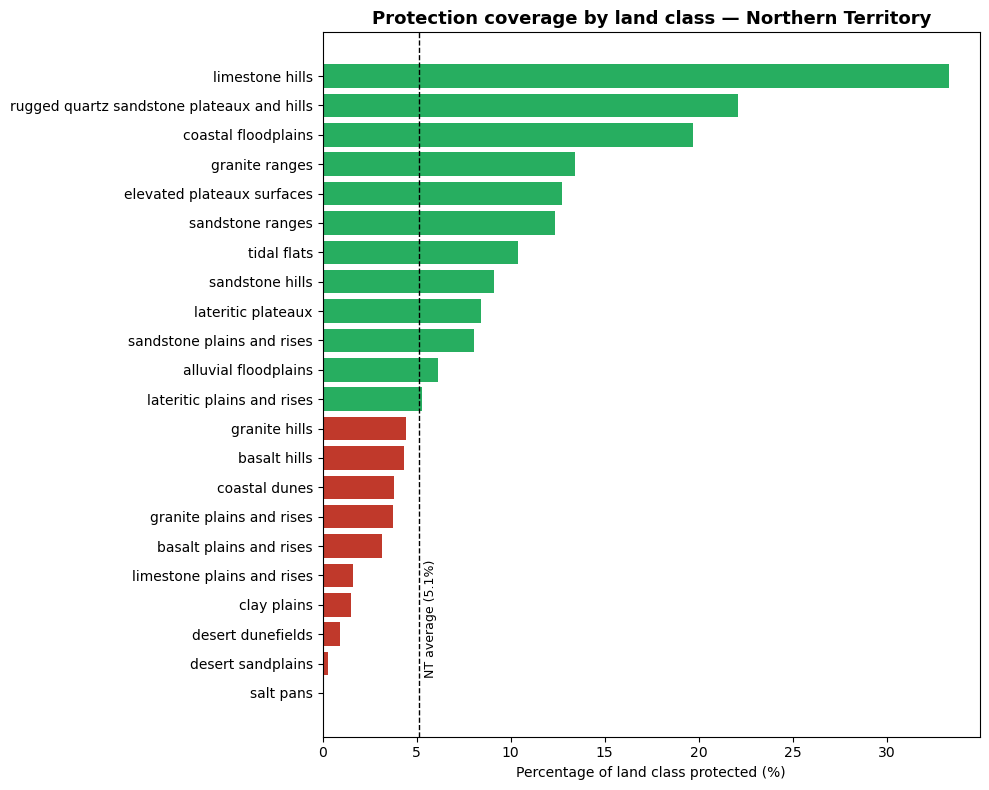

In [8]:
import matplotlib.pyplot as plt

nt_avg = 68727.4 / 1347051.3 * 100   # the 5.1% reference line

fig, ax = plt.subplots(figsize=(10, 8))
summary_sorted = summary.sort_values("pct_protected")
colors = ["#c0392b" if v < nt_avg else "#27ae60" for v in summary_sorted["pct_protected"]]

ax.barh(summary_sorted.index, summary_sorted["pct_protected"], color=colors)
ax.axvline(nt_avg, color="black", linestyle="--", linewidth=1)
ax.text(nt_avg + 0.3, 0.5, f"NT average ({nt_avg:.1f}%)", rotation=90, va="bottom", fontsize=9)
ax.set_xlabel("Percentage of land class protected (%)")
ax.set_title("Protection coverage by land class — Northern Territory", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

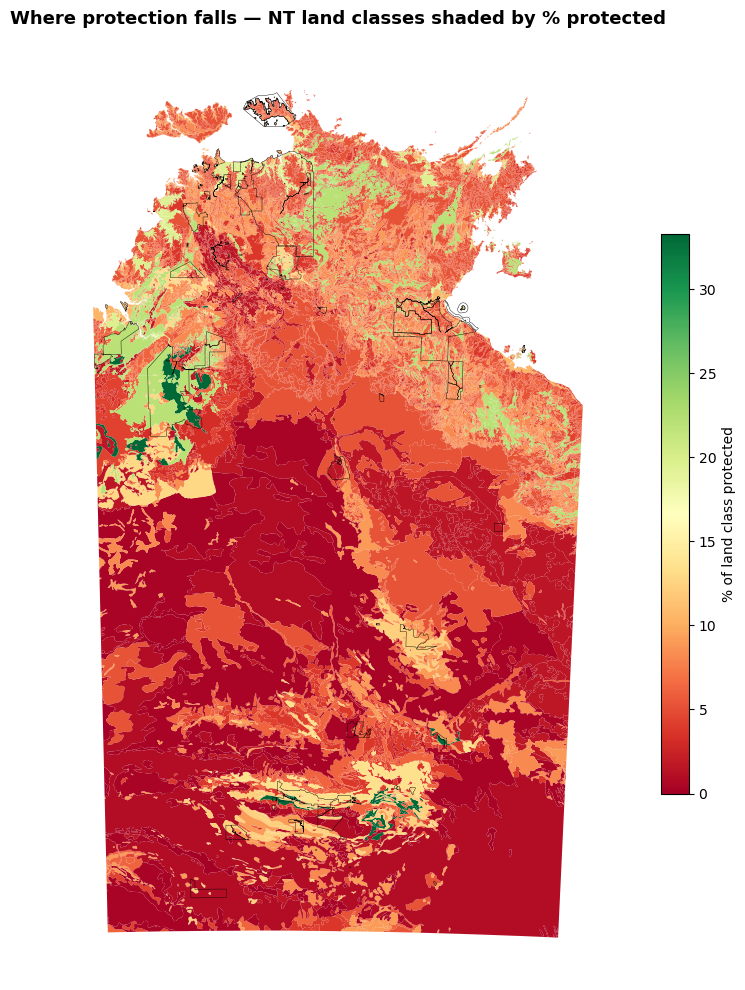

In [9]:
# Attach each polygon's protection-by-class percentage back onto the geometry, then map it
land_map = land_eq.merge(
    summary[["pct_protected"]],
    left_on="CLASS",
    right_index=True,
    how="left"
)

fig, ax = plt.subplots(figsize=(11, 10))
land_map.plot(
    column="pct_protected",
    cmap="RdYlGn",            # red = low protection, green = high
    legend=True,
    legend_kwds={"label": "% of land class protected", "shrink": 0.6},
    ax=ax,
    linewidth=0
)

# Overlay the actual park boundaries in a thin outline for context
parks_eq.boundary.plot(ax=ax, color="black", linewidth=0.3)

ax.set_title("Where protection falls — NT land classes shaded by % protected",
             fontsize=13, weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [10]:
for col in ["LANDFORM", "SOIL_ASC", "VEGETATION", "GEO_ZONE"]:
    print(f"\n=== {col} ===")
    print("unique values:", land_eq[col].nunique())
    print(land_eq[col].value_counts().head(8))


=== LANDFORM ===
unique values: 342
LANDFORM
Rugged rocky plateaux and steep, linear ridges, on massive sandstones such as the Bukalara and Kombolgie Sandstones    587
Gently undulating sandplains                                                                                           552
Level tidal flats with channels and estuaries and minor dunes                                                          518
Level to gently undulating alluvial floodplains of dominantly sandy alluvium                                           505
Level to gently undulating plains on deeply weathered rocks                                                            333
Gently undulating to undulating rises with abundant, often linear rocky outcrops                                       333
Undulating to rolling low hills on mainly argillaceous sediments                                                       313
Broad or narrow fluvial corridors conducting regional drainage across various land systems to

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Work on a clean copy with the columns we'll use
feat = land_eq[["GEO_ZONE", "CLASS", "area_km2", "geometry"]].copy()

# Check nulls before we build anything
print("Nulls per column:")
print(feat[["GEO_ZONE", "CLASS", "area_km2"]].isna().sum())
print("\nRows total:", len(feat))

Nulls per column:
GEO_ZONE    0
CLASS       0
area_km2    0
dtype: int64

Rows total: 16831


Feature matrix shape: (16831, 27)


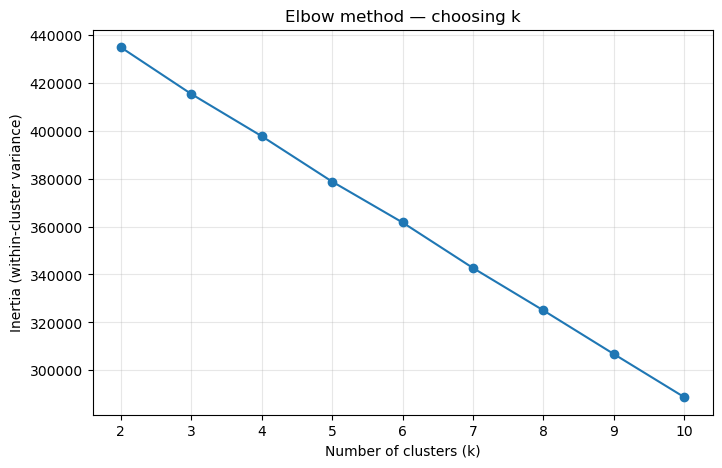

In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- Build the feature matrix ---
# One-hot encode the clean categorical bioregion (26 -> 26 columns)
geo_dummies = pd.get_dummies(land_eq["GEO_ZONE"], prefix="zone")

# Numeric feature: polygon area (log-scaled, since areas span huge orders of magnitude)
area_feat = np.log1p(land_eq["area_km2"]).rename("log_area")

# Combine
X = pd.concat([geo_dummies, area_feat], axis=1)

# Scale everything so no single feature dominates by sheer magnitude
X_scaled = StandardScaler().fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)   # rows x features

# --- Elbow test: try k = 2 through 10 ---
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the elbow
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker="o")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia (within-cluster variance)")
ax.set_title("Elbow method — choosing k")
ax.grid(alpha=0.3)
plt.show()

In [13]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in [4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=3000, random_state=42)
    print(f"k={k}:  silhouette = {score:.3f}")

k=4:  silhouette = 0.081
k=5:  silhouette = 0.188
k=6:  silhouette = 0.213


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Combine the three rich text columns into one description per polygon
text = (
    land_eq["VEGETATION"].fillna("") + " " +
    land_eq["SOIL_ASC"].fillna("")  + " " +
    land_eq["LANDFORM"].fillna("")
)

# TF-IDF vectorise
# - stop_words: drop common English filler ("the", "of", "and")
# - max_features: keep the 200 most informative terms (keeps it manageable)
# - min_df: ignore words appearing in fewer than 5 polygons (drops rare noise)
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=200,
    min_df=5
)
X_text = vectorizer.fit_transform(text)

print("Text feature matrix shape:", X_text.shape)   # rows x terms
print("\nSample of terms extracted:")
print(vectorizer.get_feature_names_out()[:40])

Text feature matrix shape: (16831, 200)

Sample of terms extracted:
['abundant' 'acacia' 'alluvial' 'alluvium' 'aquic' 'areas' 'argillaceous'
 'aristida' 'arnhem' 'auriculiformis' 'bare' 'basalt' 'beach' 'bigalerita'
 'bitextura' 'bleeseri' 'brachychiton' 'broad' 'brown' 'bukalara'
 'burrels' 'callitris' 'channels' 'chlorostachys' 'chromosolic'
 'chrysopogon' 'closed' 'coast' 'coastal' 'colluvial' 'confertiflora'
 'cover' 'creek' 'cretaceous' 'cunninghamii' 'cyperus' 'deep' 'deeply'
 'dense' 'depressions']


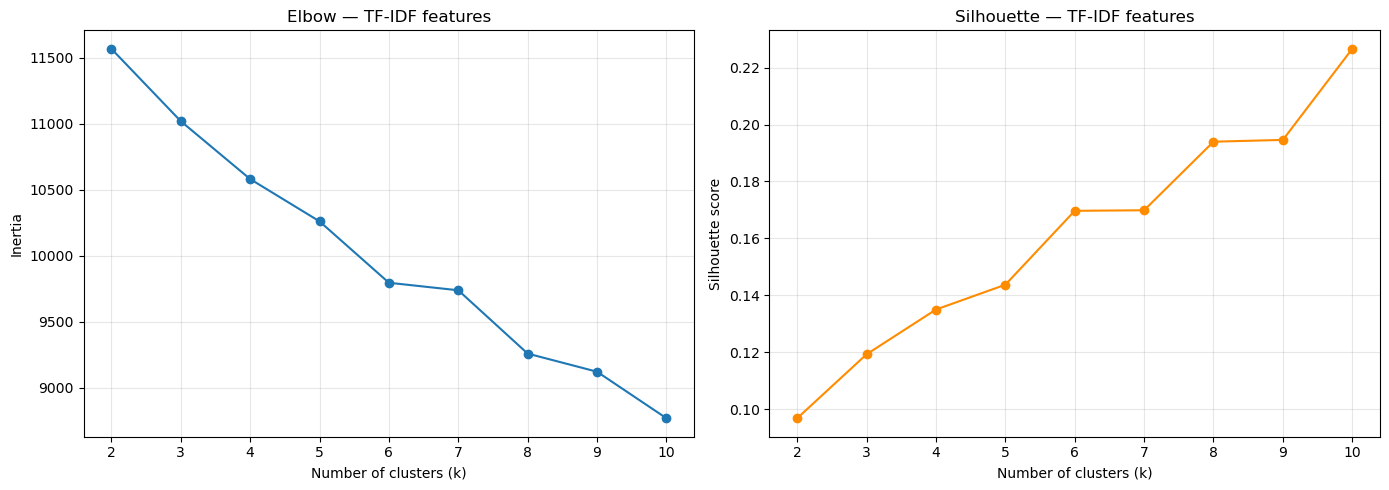

k=2:  silhouette = 0.097
k=3:  silhouette = 0.119
k=4:  silhouette = 0.135
k=5:  silhouette = 0.144
k=6:  silhouette = 0.170
k=7:  silhouette = 0.170
k=8:  silhouette = 0.194
k=9:  silhouette = 0.195
k=10:  silhouette = 0.227


In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Elbow + silhouette on the TF-IDF features
inertias = []
sils = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_text)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_text, labels, sample_size=3000, random_state=42))

# Plot both side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertias, marker="o")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow — TF-IDF features")
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), sils, marker="o", color="darkorange")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette — TF-IDF features")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print the silhouette numbers too
for k, s in zip(k_range, sils):
    print(f"k={k}:  silhouette = {s:.3f}")

In [17]:
import pandas as pd

# Final clustering on the text features, k=6
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
land_eq["cluster"] = km_final.fit_predict(X_text)

# How big is each cluster, and how protected is it?
# Bring protection back: protected_land has CLASS but we need cluster-level.
# Recompute protected area per cluster via the same overlay result.

# First, attach cluster labels onto the overlay pieces by index join through LANDSYSTEM+MAPUNIT
# Simpler & robust: recompute protected area per cluster directly.
cluster_total = land_eq.groupby("cluster")["area_km2"].sum()

# Map cluster labels onto protected_land using a key both share.
# protected_land came from land_eq, so it retains the original columns:
protected_land["cluster"] = km_final.predict(
    vectorizer.transform(
        protected_land["VEGETATION"].fillna("") + " " +
        protected_land["SOIL_ASC"].fillna("")  + " " +
        protected_land["LANDFORM"].fillna("")
    )
)
cluster_protected = protected_land.groupby("cluster")["protected_km2"].sum()

cluster_summary = pd.DataFrame({
    "total_km2": cluster_total,
    "protected_km2": cluster_protected
}).fillna(0)
cluster_summary["pct_protected"] = cluster_summary["protected_km2"] / cluster_summary["total_km2"] * 100

print(cluster_summary.round(2))

          total_km2  protected_km2  pct_protected
cluster                                          
0           7783.20        1246.14          16.01
1          77025.46       13134.23          17.05
2          22553.29        2082.46           9.23
3          21575.07        1579.03           7.32
4           7774.70         944.58          12.15
5        1210339.54       49740.96           4.11


In [18]:
import numpy as np

terms = vectorizer.get_feature_names_out()
centroids = km_final.cluster_centers_

print("Top defining terms per cluster:\n")
for c in range(6):
    top_idx = centroids[c].argsort()[::-1][:10]   # 10 highest-weighted terms
    top_terms = [terms[i] for i in top_idx]
    size = (land_eq["cluster"] == c).sum()
    pct = cluster_summary.loc[c, "pct_protected"]
    print(f"Cluster {c}  (n={size}, {pct:.1f}% protected)")
    print("   ", ", ".join(top_terms))
    print()

Top defining terms per cluster:

Cluster 0  (n=700, 16.0% protected)
    melaleuca, pseudopogonatherum, dominantly, kandosolic, spinescens, alluvial, alluvium, nervosa, chromosolic, viridiflora

Cluster 1  (n=3113, 17.1% protected)
    spp, tall, undulating, kandosols, erythrophleum, chlorostachys, tetrodonta, tectifica, sorghum, heteropogon

Cluster 2  (n=809, 9.2% protected)
    sandstones, massive, shallow, bukalara, rocky, dichromophloia, pungens, plectrachne, kombolgie, linear

Cluster 3  (n=706, 7.3% protected)
    sandplains, intratropica, callitris, tropical, triticeus, tall, grass, heteropogon, orthic, bleeseri

Cluster 4  (n=549, 12.1% protected)
    estuaries, tidal, channels, intertidal, supratidal, mangrove, samphire, sedgeland, flats, dunes

Cluster 5  (n=10954, 4.1% protected)
    leptic, open, rudosols, spp, mid, high, woodland, undulating, sorghum, low



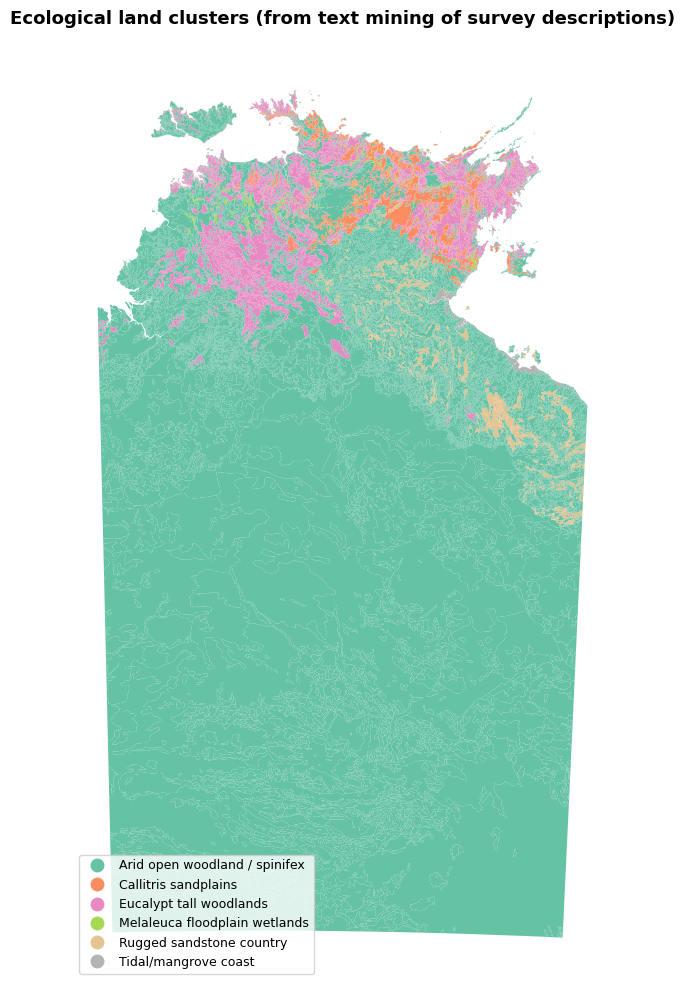

In [19]:
import matplotlib.pyplot as plt

# Give clusters readable names
cluster_names = {
    0: "Melaleuca floodplain wetlands",
    1: "Eucalypt tall woodlands",
    2: "Rugged sandstone country",
    3: "Callitris sandplains",
    4: "Tidal/mangrove coast",
    5: "Arid open woodland / spinifex",
}
land_eq["cluster_name"] = land_eq["cluster"].map(cluster_names)

# Map: NT shaded by ecological cluster
fig, ax = plt.subplots(figsize=(11, 10))
land_eq.plot(column="cluster_name", categorical=True, legend=True,
             cmap="Set2", linewidth=0, ax=ax,
             legend_kwds={"loc": "lower left", "fontsize": 9})
ax.set_title("Ecological land clusters (from text mining of survey descriptions)",
             fontsize=13, weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [20]:
import sys
!{sys.executable} -m pip install esda libpysal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 6.4 MB/s  0:00:00m 6.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [esda]


In [21]:
import geopandas as gpd
import numpy as np

# Aggregate protection to bioregion (GEO_ZONE) level
zone_total = land_eq.groupby("GEO_ZONE")["area_km2"].sum()
zone_prot  = protected_land.groupby("GEO_ZONE")["protected_km2"].sum()

# Dissolve geometries to one polygon per bioregion
zones = land_eq.dissolve(by="GEO_ZONE")[["geometry"]].copy()
zones["total_km2"]     = zone_total
zones["protected_km2"] = zone_prot.reindex(zones.index).fillna(0)
zones["pct_protected"] = zones["protected_km2"] / zones["total_km2"] * 100

# Fix any invalid geometry from the dissolve
zones["geometry"] = zones.geometry.buffer(0)

print("Bioregions:", len(zones))
print(zones[["total_km2", "protected_km2", "pct_protected"]].round(1).sort_values("pct_protected"))

Bioregions: 26
                               total_km2  protected_km2  pct_protected
GEO_ZONE                                                              
Gulf Plains                       2047.5            0.0            0.0
Central Arnhem                   24467.0            0.0            0.0
Central Ranges                    7934.5            0.0            0.0
Channel Country                  18749.7            1.7            0.0
Mount Isa Inlier                   287.9            0.0            0.0
Great Sandy Desert                9499.8            4.0            0.0
Stony Plains                       373.7            0.0            0.0
Sturt Plateau                    87647.1          115.5            0.1
Finke                            16834.6           76.3            0.5
Arnhem Coast                     45506.8          279.5            0.6
Tanami                          538136.2         3147.5            0.6
Simpson Strzelecki Dunefields     4583.6           30.4       

In [22]:
from libpysal.weights import Queen
from esda.moran import Moran
import numpy as np

# Build spatial weights: which bioregions share a border ("Queen" contiguity)
w = Queen.from_dataframe(zones, use_index=True)
w.transform = "r"   # row-standardise (standard practice)

# Report how connected the regions are
print("Average neighbours per region:", round(w.mean_neighbors, 2))
print("Any islands (regions with no neighbours)?:", w.islands)

# Global Moran's I on protection %
y = zones["pct_protected"].values
moran = Moran(y, w, permutations=999)

print(f"\nMoran's I: {moran.I:.3f}")
print(f"Expected I if random: {moran.EI:.3f}")
print(f"p-value (999 permutations): {moran.p_sim:.4f}")

Average neighbours per region: 5.08
Any islands (regions with no neighbours)?: []

Moran's I: 0.227
Expected I if random: -0.040
p-value (999 permutations): 0.0320


In [23]:
from esda.getisord import G_Local
import numpy as np

# Getis-Ord Gi* — local hot/cold spot statistic
gi = G_Local(y, w, permutations=999, star=True)

zones["gi_z"]   = gi.Zs        # z-score: + = hot spot, - = cold spot
zones["gi_p"]   = gi.p_sim     # significance

# Classify into hot / cold / not significant
def classify(row):
    if row["gi_p"] >= 0.05:
        return "Not significant"
    return "Hot spot (high protection)" if row["gi_z"] > 0 else "Cold spot (low protection)"

zones["gi_class"] = zones.apply(classify, axis=1)

print(zones[["pct_protected", "gi_z", "gi_p", "gi_class"]]
      .sort_values("gi_z", ascending=False).round(3))

/opt/anaconda3/envs/ntgis/lib/python3.11/site-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


                               pct_protected   gi_z   gi_p  \
GEO_ZONE                                                     
Pine Creek                            33.507  1.275  0.012   
Darwin Coastal                        32.864  1.132  0.008   
Daly Basin                             1.656  0.790  0.004   
Victoria Bonaparte Coast               9.464  0.725  0.158   
Arnhem Plateau                        26.534  0.717  0.059   
Arnhem Coast                           0.614  0.700  0.021   
Tiwi Cobourg                          19.180  0.236  0.410   
Victoria Bonaparte                    20.585  0.195  0.408   
Central Arnhem                         0.000  0.163  0.196   
Gulf Plains                            0.000  0.116  0.250   
Gulf Coastal                          16.531  0.116  0.495   
Gulf Fall and Uplands                  9.399  0.026  0.482   
Ord Victoria Plain                     0.982 -0.251  0.378   
Sturt Plateau                          0.132 -0.263  0.277   
Mount Is

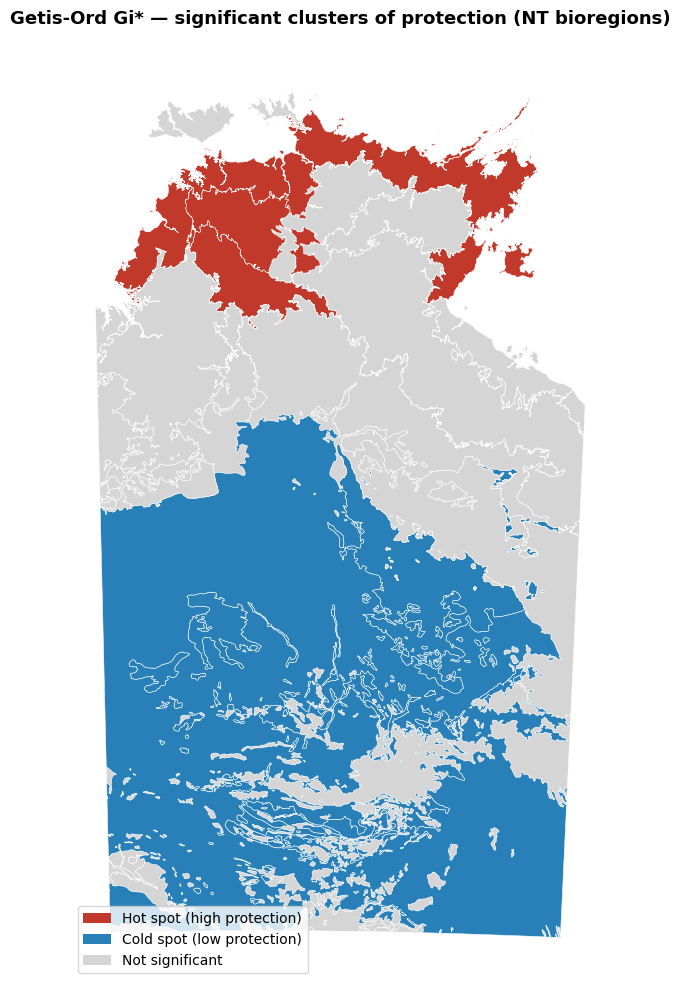

In [24]:
import matplotlib.pyplot as plt

color_map = {
    "Hot spot (high protection)": "#c0392b",
    "Cold spot (low protection)": "#2980b9",
    "Not significant": "#d5d5d5",
}
zones["color"] = zones["gi_class"].map(color_map)

fig, ax = plt.subplots(figsize=(11, 10))
zones.plot(color=zones["color"], edgecolor="white", linewidth=0.4, ax=ax)

# Manual legend
from matplotlib.patches import Patch
legend = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend, loc="lower left", fontsize=10)

ax.set_title("Getis-Ord Gi* — significant clusters of protection (NT bioregions)",
             fontsize=13, weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [25]:
import os
os.makedirs("figures", exist_ok=True)

# 1. Bar chart — protection by class
fig, ax = plt.subplots(figsize=(10, 8))
nt_avg = 68727.4 / 1347051.3 * 100
ss = summary.sort_values("pct_protected")
colors = ["#c0392b" if v < nt_avg else "#27ae60" for v in ss["pct_protected"]]
ax.barh(ss.index, ss["pct_protected"], color=colors)
ax.axvline(nt_avg, color="black", linestyle="--", linewidth=1)
ax.text(nt_avg + 0.3, len(ss) - 1.5, f"NT average ({nt_avg:.1f}%)", rotation=90, va="top", fontsize=9)
ax.set_xlabel("Percentage of land class protected (%)")
ax.set_title("Protection coverage by land class — Northern Territory", fontsize=13, weight="bold")
plt.tight_layout()
fig.savefig("figures/01_protection_by_class.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 2. Choropleth — protection by class, mapped
land_map = land_eq.merge(summary[["pct_protected"]], left_on="CLASS", right_index=True, how="left")
fig, ax = plt.subplots(figsize=(11, 10))
land_map.plot(column="pct_protected", cmap="RdYlGn", legend=True,
              legend_kwds={"label": "% of land class protected", "shrink": 0.6}, ax=ax, linewidth=0)
parks_eq.boundary.plot(ax=ax, color="black", linewidth=0.3)
ax.set_title("Where protection falls — NT land classes shaded by % protected", fontsize=13, weight="bold")
ax.set_axis_off()
plt.tight_layout()
fig.savefig("figures/02_protection_map.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 3. Cluster map
fig, ax = plt.subplots(figsize=(11, 10))
land_eq.plot(column="cluster_name", categorical=True, legend=True, cmap="Set2",
             linewidth=0, ax=ax, legend_kwds={"loc": "lower left", "fontsize": 9})
ax.set_title("Ecological land clusters (from text mining of survey descriptions)", fontsize=13, weight="bold")
ax.set_axis_off()
plt.tight_layout()
fig.savefig("figures/03_ecological_clusters.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 4. Getis-Ord Gi* map
from matplotlib.patches import Patch
color_map = {"Hot spot (high protection)": "#c0392b",
             "Cold spot (low protection)": "#2980b9",
             "Not significant": "#d5d5d5"}
zones["color"] = zones["gi_class"].map(color_map)
fig, ax = plt.subplots(figsize=(11, 10))
zones.plot(color=zones["color"], edgecolor="white", linewidth=0.4, ax=ax)
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in color_map.items()],
          loc="lower left", fontsize=10)
ax.set_title("Getis-Ord Gi* — significant clusters of protection (NT bioregions)", fontsize=13, weight="bold")
ax.set_axis_off()
plt.tight_layout()
fig.savefig("figures/04_hotspot_map.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved 4 figures to the 'figures/' folder.")
print("Files:", os.listdir("figures"))

Saved 4 figures to the 'figures/' folder.
Files: ['04_hotspot_map.png', '02_protection_map.png', '03_ecological_clusters.png', '01_protection_by_class.png']


In [26]:
import os, json
os.makedirs("app_data", exist_ok=True)

# 1. Bioregions with all stats + geometry, reprojected to WGS84 (what web maps use)
zones_web = zones.to_crs(4326).copy()
zones_web = zones_web.reset_index()  # GEO_ZONE becomes a column
keep = ["GEO_ZONE", "total_km2", "protected_km2", "pct_protected", "gi_z", "gi_p", "gi_class", "geometry"]
zones_web[keep].to_file("app_data/bioregions.geojson", driver="GeoJSON")

# 2. Protection-by-class table
summary.reset_index().to_json("app_data/by_class.json", orient="records", indent=2)

# 3. Cluster summary with names
cs = cluster_summary.copy()
cs["cluster_name"] = cs.index.map({
    0: "Melaleuca floodplain wetlands", 1: "Eucalypt tall woodlands",
    2: "Rugged sandstone country", 3: "Callitris sandplains",
    4: "Tidal/mangrove coast", 5: "Arid open woodland / spinifex"})
cs.reset_index().to_json("app_data/by_cluster.json", orient="records", indent=2)

print("Wrote:", os.listdir("app_data"))
print("Bioregion file size (MB):", round(os.path.getsize("app_data/bioregions.geojson")/1e6, 2))

Wrote: ['by_class.json', 'by_cluster.json', 'bioregions.geojson']
Bioregion file size (MB): 26.16


In [27]:
import os

# Simplify geometry: tolerance in degrees (~0.01 deg ≈ 1 km, invisible at NT-wide zoom)
zones_web_simplified = zones_web.copy()
zones_web_simplified["geometry"] = zones_web_simplified.geometry.simplify(
    tolerance=0.01, preserve_topology=True
)

keep = ["GEO_ZONE", "total_km2", "protected_km2", "pct_protected",
        "gi_z", "gi_p", "gi_class", "geometry"]
zones_web_simplified[keep].to_file("app_data/bioregions.geojson", driver="GeoJSON")

new_size = os.path.getsize("app_data/bioregions.geojson") / 1e6
print("New bioregion file size (MB):", round(new_size, 2))

New bioregion file size (MB): 1.26
